In [ ]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, svm, tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_graphviz
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
%matplotlib inline

ЗАДАНИЕ 1: МЕТОД ОПОРНЫХ ВЕКТОРОВ

НАБОР ДАННЫХ 1: Линейно разделимый


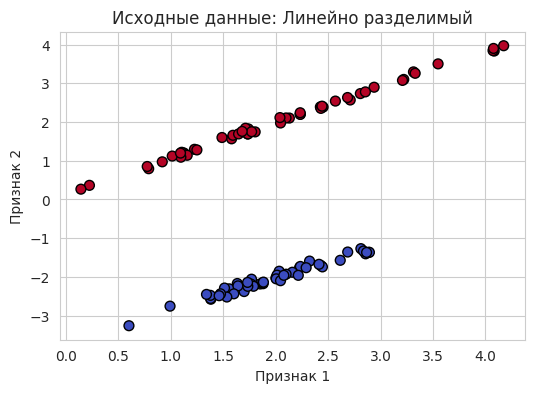


ТЕСТИРОВАНИЕ РАЗНЫХ ЯДЕР:

--- Ядро: linear ---


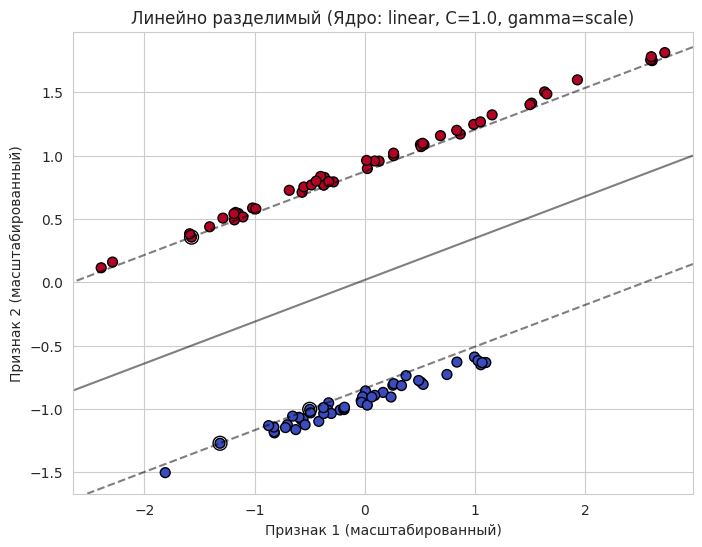

Точность: 1.000
Количество опорных векторов: 3
Время обучения: 0.5322 сек

--- Ядро: rbf ---


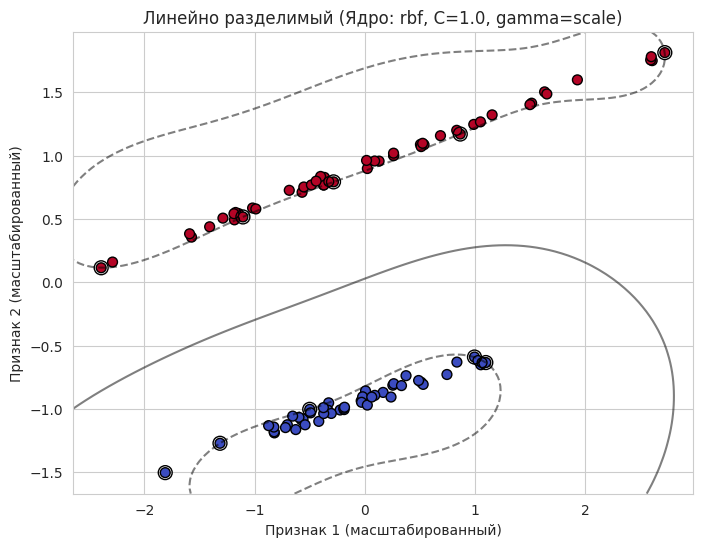

Точность: 1.000
Количество опорных векторов: 10
Время обучения: 0.4714 сек

--- Ядро: poly ---


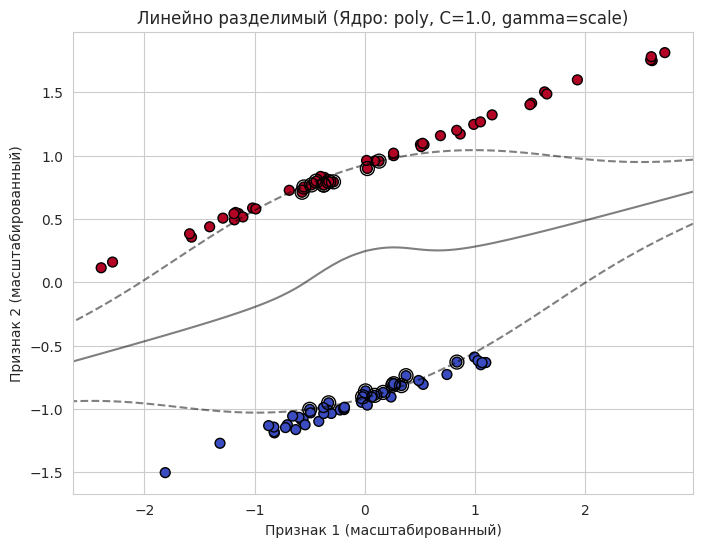

Точность: 1.000
Количество опорных векторов: 21
Время обучения: 0.4075 сек

--- ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ---
Лучшие параметры: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
Лучшая точность (CV): 1.0

ВИЗУАЛИЗАЦИЯ С ЛУЧШИМИ ПАРАМЕТРАМИ:


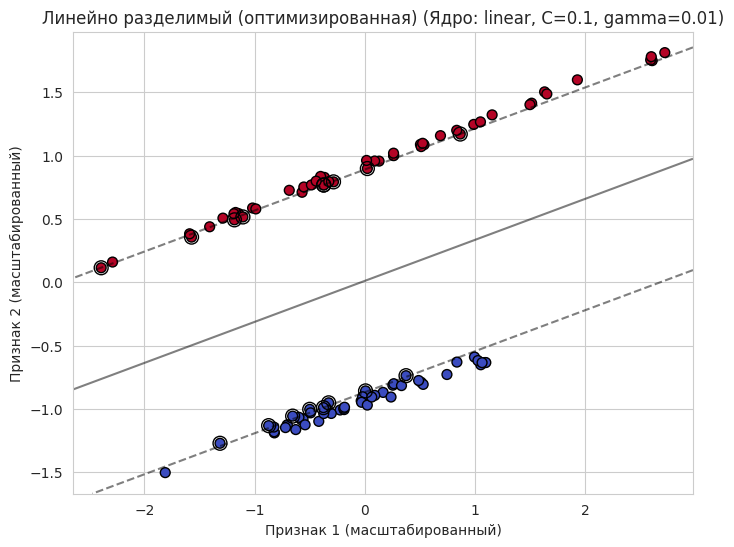

Точность: 1.000
Количество опорных векторов: 17

НАБОР ДАННЫХ 2: С перекрытием классов


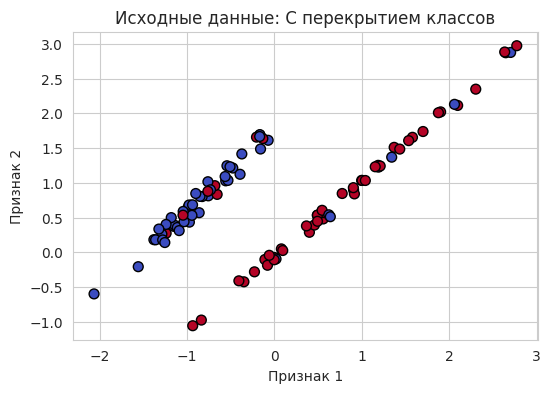


ТЕСТИРОВАНИЕ РАЗНЫХ ЯДЕР:

--- Ядро: linear ---


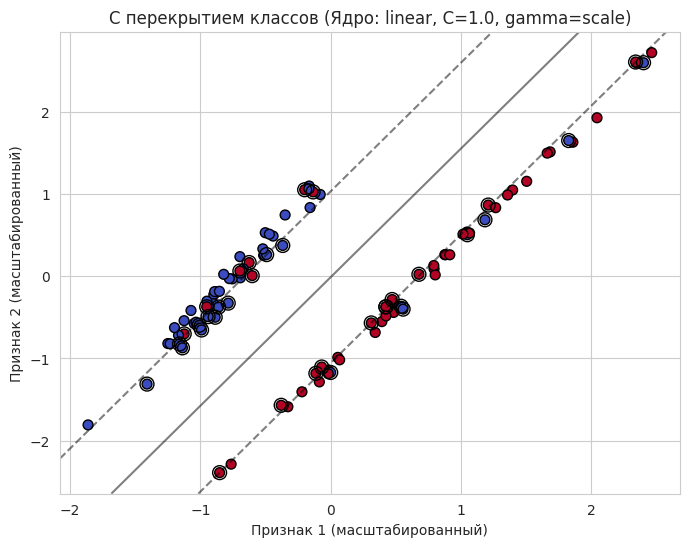

Точность: 0.860
Количество опорных векторов: 36
Время обучения: 0.4861 сек

--- Ядро: rbf ---


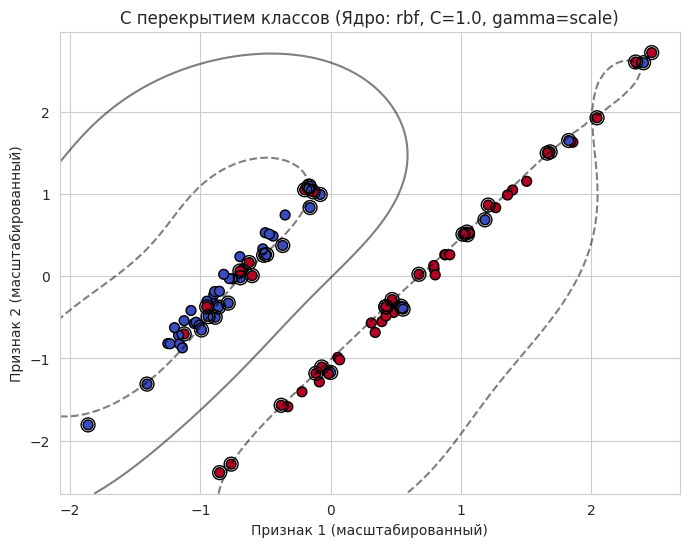

Точность: 0.860
Количество опорных векторов: 46
Время обучения: 0.4550 сек

--- Ядро: poly ---


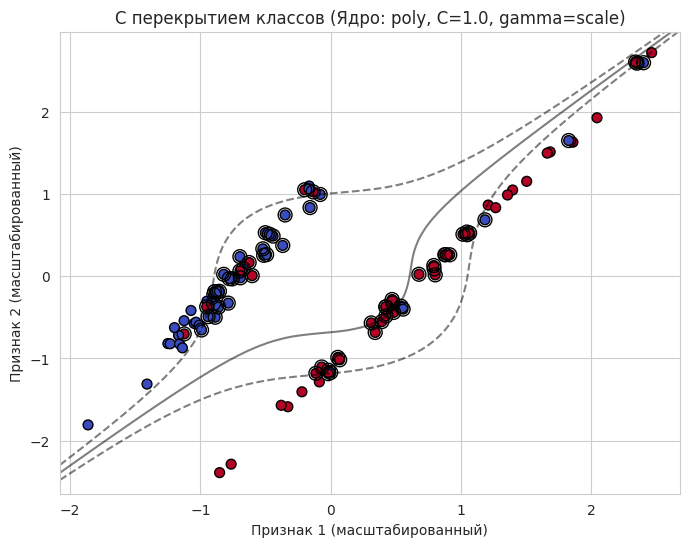

Точность: 0.800
Количество опорных векторов: 67
Время обучения: 0.4009 сек

--- ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ---
Лучшие параметры: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
Лучшая точность (CV): 0.86

ВИЗУАЛИЗАЦИЯ С ЛУЧШИМИ ПАРАМЕТРАМИ:


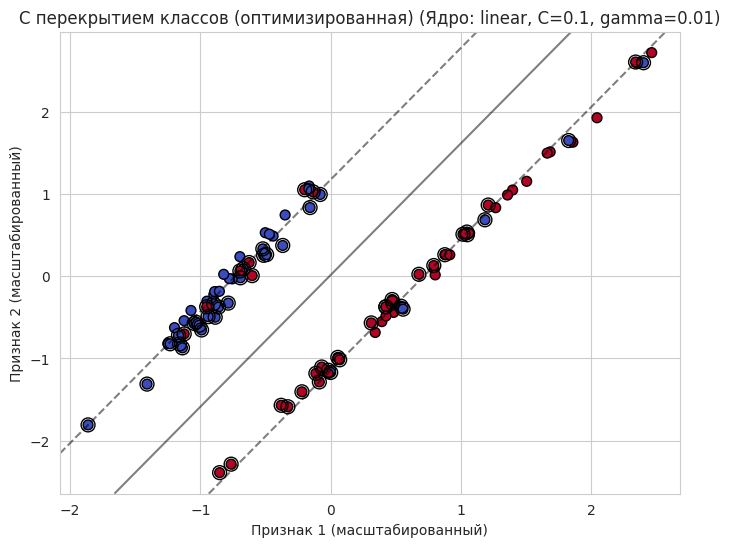

Точность: 0.860
Количество опорных векторов: 60

НАБОР ДАННЫХ 3: Нелинейно разделимый


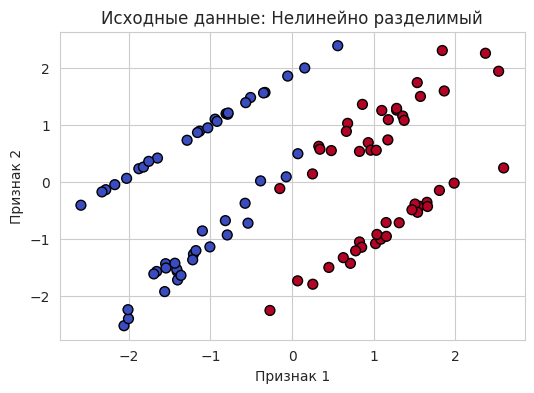


ТЕСТИРОВАНИЕ РАЗНЫХ ЯДЕР:

--- Ядро: linear ---


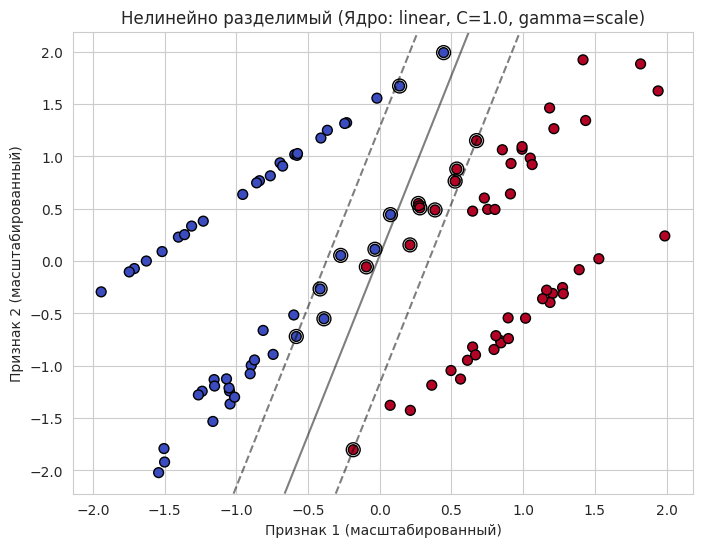

Точность: 0.990
Количество опорных векторов: 17
Время обучения: 0.6930 сек

--- Ядро: rbf ---


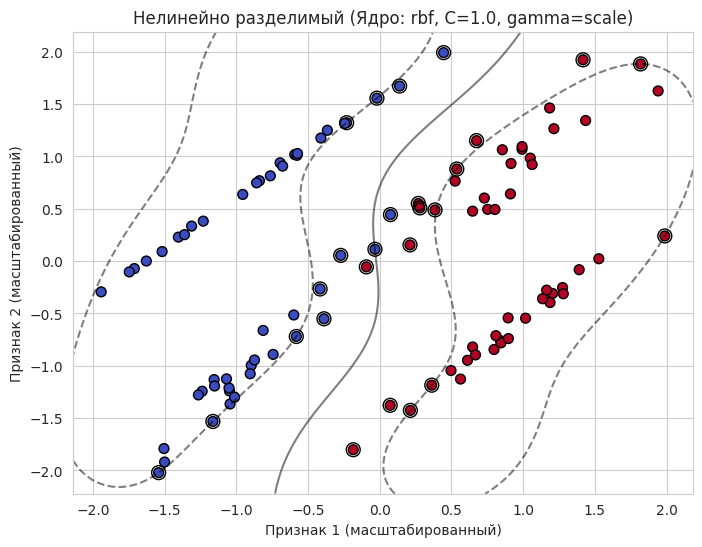

Точность: 0.970
Количество опорных векторов: 26
Время обучения: 1.0558 сек

--- Ядро: poly ---


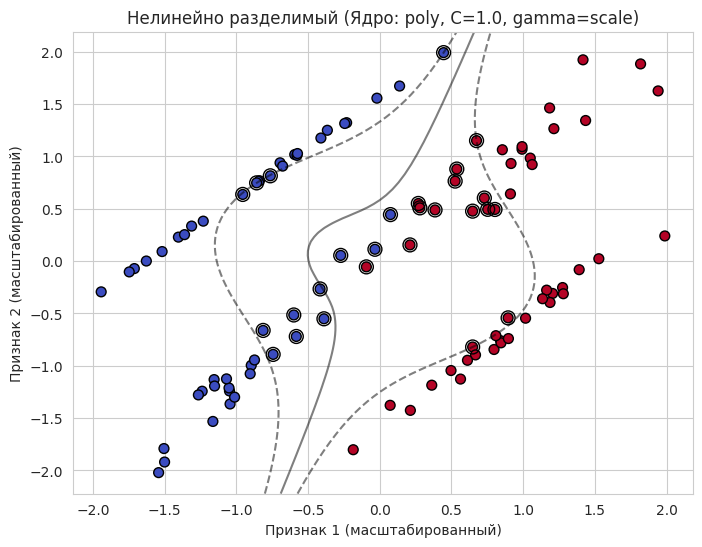

Точность: 0.970
Количество опорных векторов: 27
Время обучения: 0.6997 сек

--- ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ---
Лучшие параметры: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Лучшая точность (CV): 0.99

ВИЗУАЛИЗАЦИЯ С ЛУЧШИМИ ПАРАМЕТРАМИ:


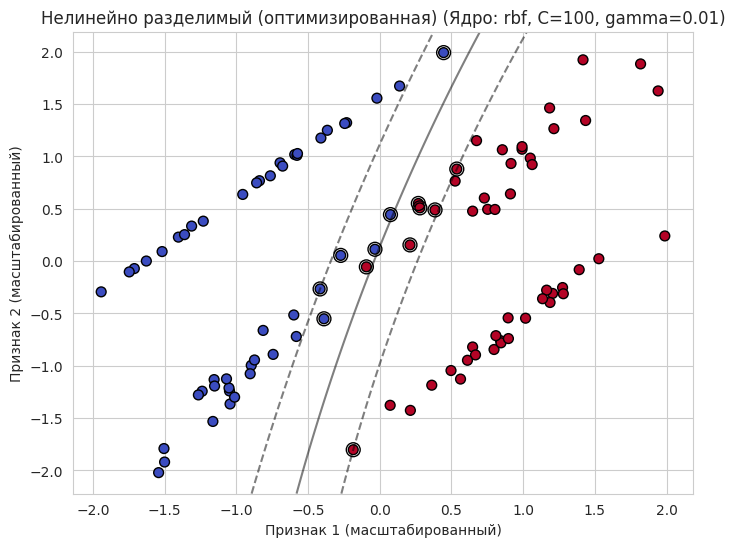

Точность: 0.990
Количество опорных векторов: 13


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import time

# Настройка графиков
plt.rcParams['figure.figsize'] = (10, 8)
%matplotlib inline

# 2. Генерация трех наборов данных
def generate_datasets():
    # Линейно разделимый
    X1, y1 = make_classification(
        n_samples=100, n_features=2, n_redundant=0, n_informative=2,
        n_clusters_per_class=1, class_sep=2.0, random_state=42
    )

    # С перекрытием классов (шум)
    X2, y2 = make_classification(
        n_samples=100, n_features=2, n_redundant=0, n_informative=2,
        n_clusters_per_class=1, class_sep=0.8, flip_y=0.15, random_state=42
    )

    # Нелинейно разделимый
    X3, y3 = make_classification(
        n_samples=100, n_features=2, n_redundant=0, n_informative=2,
        n_clusters_per_class=2, random_state=42
    )

    return [(X1, y1, "Линейно разделимый"),
            (X2, y2, "С перекрытием классов"),
            (X3, y3, "Нелинейно разделимый")]

# 3. Функция для визуализации SVM
def plot_svm_results(X, y, kernel='rbf', C=1.0, gamma='scale', title=''):
    # Масштабирование признаков
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Обучение модели
    model = svm.SVC(kernel=kernel, C=C, gamma=gamma)
    model.fit(X_scaled, y)

    # Визуализация
    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', s=50, edgecolors='k')

    # Создание сетки для границы решения
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # Граница решения и зазор
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # Опорные векторы
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')

    plt.title(f'{title} (Ядро: {kernel}, C={C}, gamma={gamma})')
    plt.xlabel('Признак 1 (масштабированный)')
    plt.ylabel('Признак 2 (масштабированный)')
    plt.show()

    # Расчет точности
    accuracy = model.score(X_scaled, y)
    print(f'Точность: {accuracy:.3f}')
    print(f'Количество опорных векторов: {len(model.support_vectors_)}')
    return model

# 4. Подбор параметров с GridSearchCV
def optimize_svm(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.01, 0.1, 1, 'scale'],
        'kernel': ['linear', 'rbf', 'poly']
    }

    grid_search = GridSearchCV(
        svm.SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1
    )
    grid_search.fit(X_scaled, y)

    print("Лучшие параметры:", grid_search.best_params_)
    print("Лучшая точность (CV):", grid_search.best_score_)
    return grid_search.best_estimator_

# 5. Основной эксперимент
print("="*60)
print("ЗАДАНИЕ 1: МЕТОД ОПОРНЫХ ВЕКТОРОВ")
print("="*60)

# Генерация данных
datasets_list = generate_datasets()
kernels = ['linear', 'rbf', 'poly']

for i, (X, y, desc) in enumerate(datasets_list, 1):
    print(f"\n{'='*50}")
    print(f"НАБОР ДАННЫХ {i}: {desc}")
    print(f"{'='*50}")

    # Визуализация исходных данных
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=50, edgecolors='k')
    plt.title(f'Исходные данные: {desc}')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.show()

    # Тестирование разных ядер
    print(f"\nТЕСТИРОВАНИЕ РАЗНЫХ ЯДЕР:")
    results = {}

    for kernel in kernels:
        print(f"\n--- Ядро: {kernel} ---")
        start_time = time.time()
        model = plot_svm_results(X, y, kernel=kernel, title=desc)
        end_time = time.time()
        training_time = end_time - start_time
        accuracy = model.score(StandardScaler().fit_transform(X), y)
        results[kernel] = {'accuracy': accuracy, 'time': training_time}
        print(f"Время обучения: {training_time:.4f} сек")

    # Подбор оптимальных параметров
    print(f"\n--- ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ---")
    best_model = optimize_svm(X, y)

    # Визуализация с лучшими параметрами
    best_params = best_model.get_params()
    print(f"\nВИЗУАЛИЗАЦИЯ С ЛУЧШИМИ ПАРАМЕТРАМИ:")
    plot_svm_results(X, y,
                    kernel=best_params['kernel'],
                    C=best_params['C'],
                    gamma=best_params['gamma'],
                    title=f'{desc} (оптимизированная)')





Обучающая выборка: 400 samples
Тестовая выборка: 100 samples

Дерево (по умолчанию):
Точность: 0.9900
Глубина дерева: 6

Дерево (max_depth=3):
Точность: 1.0000


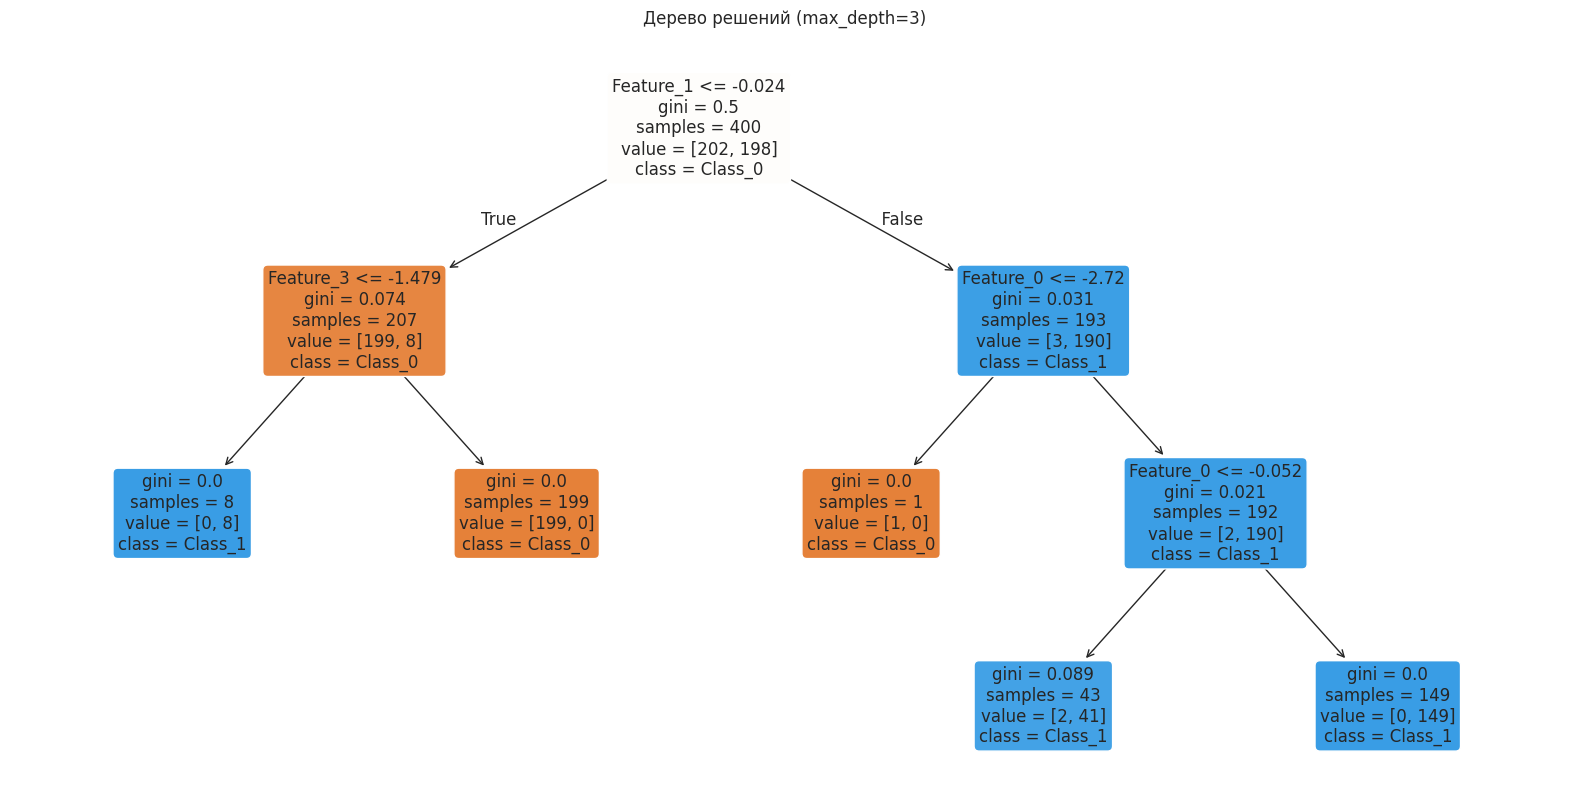

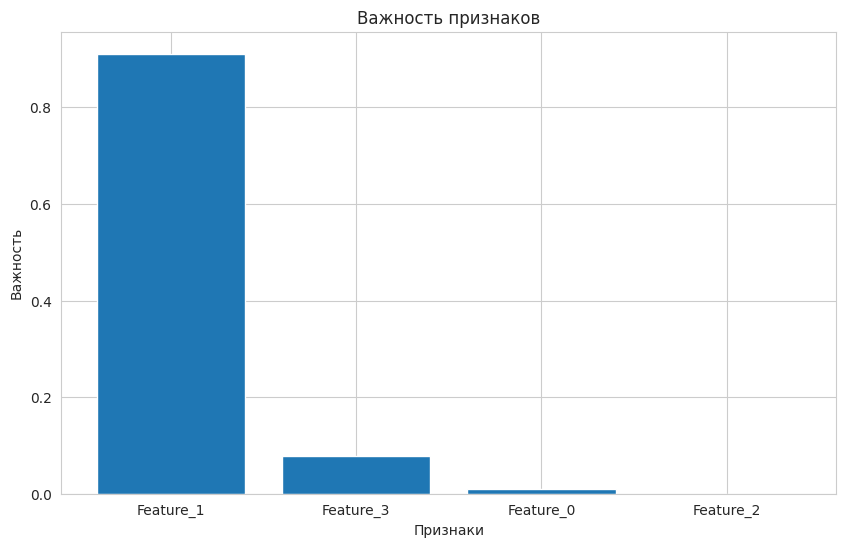

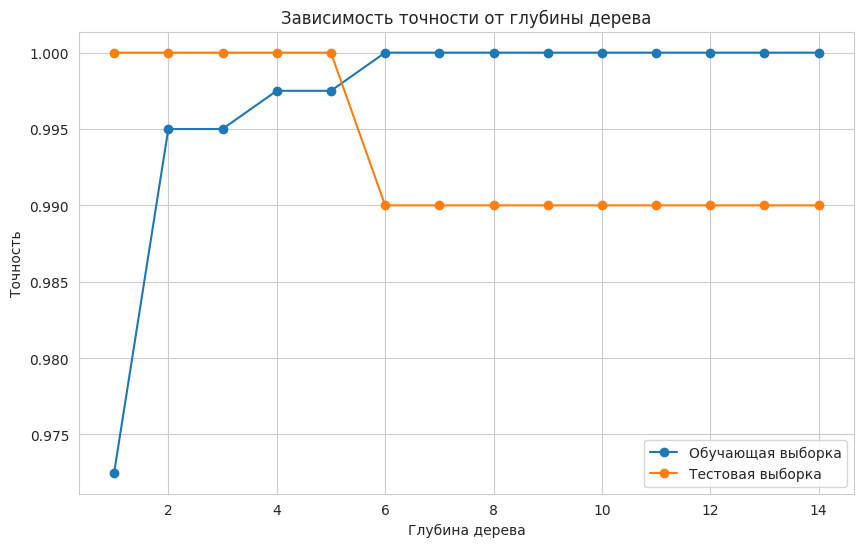

In [ ]:

student_number = 7

X, y = make_classification(
    n_samples=500, n_features=4, n_informative=3, n_redundant=1,
    n_clusters_per_class=1, random_state=student_number
)

# 2. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=student_number, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

# 3. Дерево с параметрами по умолчанию
dt_default = DecisionTreeClassifier(random_state=student_number)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)

print(f"\nДерево (по умолчанию):")
print(f"Точность: {acc_default:.4f}")
print(f"Глубина дерева: {dt_default.get_depth()}")

# 4. Дерево с ограничением глубины
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=student_number)
dt_limited.fit(X_train, y_train)

y_pred_limited = dt_limited.predict(X_test)
acc_limited = accuracy_score(y_test, y_pred_limited)

print(f"\nДерево (max_depth=3):")
print(f"Точность: {acc_limited:.4f}")

# 5. Визуализация деревьев
feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
class_names = ['Class_0', 'Class_1']

# Визуализация ограниченного дерева
plt.figure(figsize=(20, 10))
plot_tree(dt_limited, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=12)
plt.title('Дерево решений (max_depth=3)')
plt.show()

# 6. Сравнение важности признаков
plt.figure(figsize=(10, 6))
importances = dt_limited.feature_importances_
indices = np.argsort(importances)[::-1]

plt.title("Важность признаков")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [f'Feature_{i}' for i in indices])
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.show()

# 7. Анализ переобучения
depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=student_number)
    dt.fit(X_train, y_train)

    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Обучающая выборка')
plt.plot(depths, test_scores, 'o-', label='Тестовая выборка')
plt.xlabel('Глубина дерева')
plt.ylabel('Точность')
plt.title('Зависимость точности от глубины дерева')
plt.legend()
plt.grid(True)
plt.show()

Обучающая выборка:
   Уровень_красноречия_высокий  Внешность_приятная  Потраченные_деньги_много  \
0                         True                True                      True   
1                        False                True                     False   
2                        False                True                      True   
3                        False               False                     False   
4                        False               False                      True   
5                         True               False                      True   
6                        False                True                      True   

   Алкоголь_в_напитке_нет  Алкоголь_в_напитке_да  Уровень_красноречия_средний  \
0                   False                   True                        False   
1                   False                   True                        False   
2                    True                  False                         True   
3               

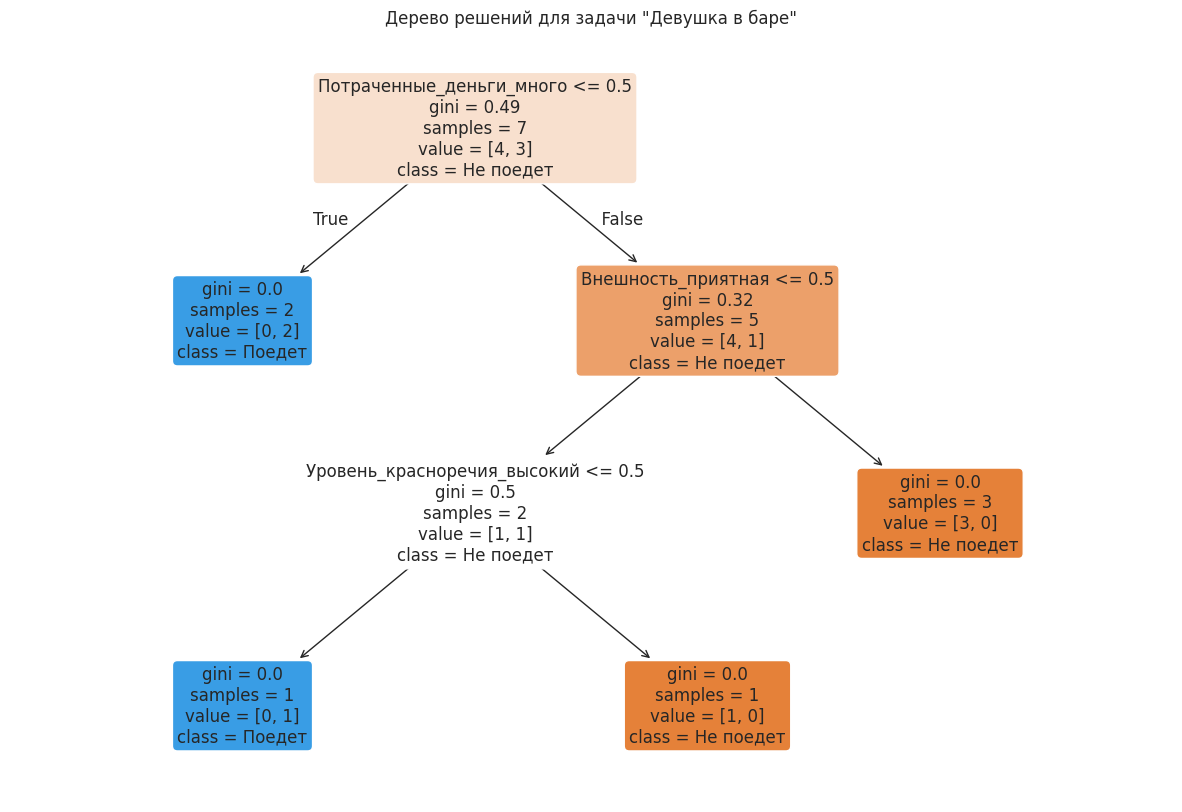

In [ ]:
# 1. Создание функций из задания
def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis=1)
    out.drop(feature_list, axis=1, inplace=True)
    return out

def intersect_features(train, test):
    common_feat = list(set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

# 2. Создание данных
features = ['Внешность', 'Алкоголь_в_напитке', 'Уровень_красноречия', 'Потраченные_деньги']

# Обучающая выборка
df_train = {}
df_train['Внешность'] = ['приятная', 'приятная', 'приятная', 'отталкивающая',
                         'отталкивающая', 'отталкивающая', 'приятная']
df_train['Алкоголь_в_напитке'] = ['да', 'да', 'нет', 'нет', 'да', 'да', 'да']
df_train['Уровень_красноречия'] = ['высокий', 'низкий', 'средний', 'средний', 'низкий',
                                   'высокий', 'средний']
df_train['Потраченные_деньги'] = ['много', 'мало', 'много', 'мало', 'много',
                                  'много', 'много']
df_train['Поедет'] = LabelEncoder().fit_transform(['+', '-', '+', '-', '-', '+', '+'])

df_train = create_df(df_train, features)

# Тестовая выборка
df_test = {}
df_test['Внешность'] = ['приятная', 'приятная', 'отталкивающая']
df_test['Алкоголь_в_напитке'] = ['нет', 'да', 'да']
df_test['Уровень_красноречия'] = ['средний', 'высокий', 'средний']
df_test['Потраченные_деньги'] = ['много', 'мало', 'много']
df_test = create_df(df_test, features)

# 3. Подготовка данных для обучения
y = df_train['Поедет']
df_train, df_test = intersect_features(train=df_train, test=df_test)

print("Обучающая выборка:")
print(df_train)
print("\nТестовая выборка:")
print(df_test)

# 4. Функции для расчета энтропии
def entropy(a_list):
    from collections import Counter
    counts = np.array(list(Counter(a_list).values()))
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

def information_gain(root, left, right):
    p = len(left) / len(root)
    return entropy(root) - p * entropy(left) - (1 - p) * entropy(right)

# 5. Расчеты для ответов на вопросы
print("\n--- Ответы на вопросы ---")

# Вопрос 1: Энтропия начальной системы
S0 = entropy([0, 1, 0, 1, 1, 0, 0])  # Поедет: [0,1,0,1,1,0,0] соответствует [+,-,+,-,-,+,+]
print(f"Вопрос 1: Энтропия S0 = {S0:.4f}")

# Вопрос 2: Разбиение по признаку "Внешность_приятная"
# (нужно посчитать вручную по данным)

# 6. Обучение дерева решений
X_train = df_train.drop('Поедет', axis=1) if 'Поедет' in df_train.columns else df_train
y_train = y

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(f"\nТочность на обучающих данных: {dt.score(X_train, y_train):.4f}")

# 7. Визуализация дерева
plt.figure(figsize=(15, 10))
plot_tree(dt, feature_names=X_train.columns.tolist(),
          class_names=['Не поедет', 'Поедет'],
          filled=True, rounded=True, fontsize=12)
plt.title('Дерево решений для задачи "Девушка в баре"')
plt.show()

In [ ]:

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test

# Переименуем для удобства
import pandas as pd

# Читаем и сохраняем с правильными именами
columns = ['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
           'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
           'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target']

# Обучающая выборка
df_train = pd.read_csv('adult.data', names=columns, sep='\s*,\s*', engine='python')
df_train.to_csv('adult_train.csv', sep=';', index=False)

# Тестовая выборка (пропускаем первую строку с описанием)
df_test = pd.read_csv('adult.test', names=columns, sep='\s*,\s*', engine='python', skiprows=1)
df_test.to_csv('adult_test.csv', sep=';', index=False)

--2025-12-11 12:23:50--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data’

adult.data              [   <=>              ]   3.79M  8.17MB/s    in 0.5s    

2025-12-11 12:23:50 (8.17 MB/s) - ‘adult.data’ saved [3974305]

--2025-12-11 12:23:51--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.test’

adult.test              [  <=>               ]   1.91M  4.65MB/s    in 0.4s    

2025-12-11 12:23:51 (4.65 MB/s) - ‘adult.test’ saved [2003153]



ШАГ 1: ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ
Размер обучающей выборки: (32561, 15)
Размер тестовой выборки: (16281, 15)

Первые 5 строк обучающей выборки:
   Age         Workclass  fnlwgt  Education  Education_Num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       Martial_Status         Occupation   Relationship   Race     Sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   Capital_Gain  Capital

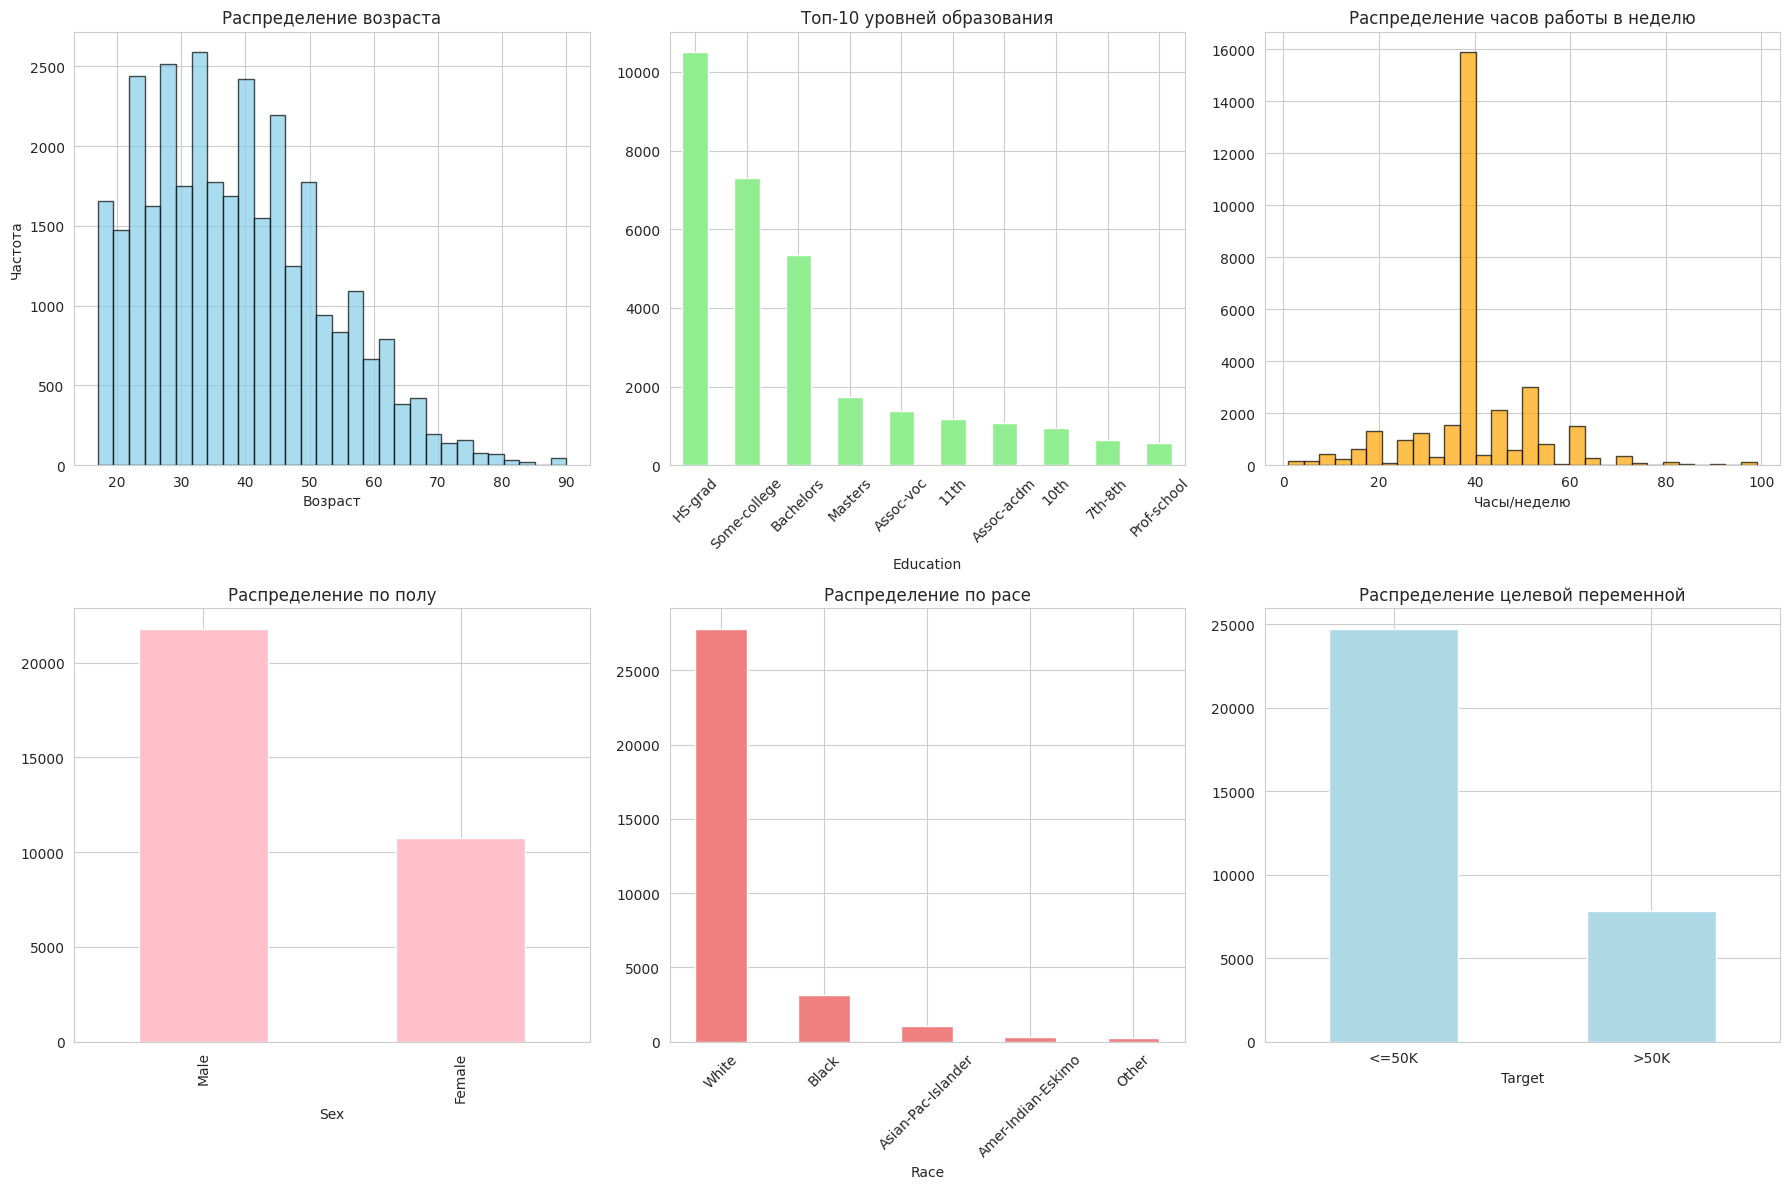


ШАГ 4: ПОДГОТОВКА ПРИЗНАКОВ И ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА
Обучающая выборка: (32561, 15)
Тестовая выборка: (16281, 15)
Кодирование категориальных признаков...
Кодирование завершено.

Обучение случайного леса...

Точность (accuracy) случайного леса на тестовой выборке: 0.8542

Отчет классификации (Random Forest):

              precision    recall  f1-score   support

           0       0.89      0.93      0.91     12435
           1       0.73      0.61      0.67      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.77      0.79     16281
weighted avg       0.85      0.85      0.85     16281


Обучение одного дерева решений для сравнения...

Точность (accuracy) дерева решений на тестовой выборке: 0.8112

Отчет классификации (Decision Tree):

              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12435
           1       0.60      0.60      0.60      3846

    accuracy                           0.81 

In [ ]:
# =============================================================================
# ЗАДАНИЕ 4: ДЕРЕВЬЯ РЕШЕНИЙ ДЛЯ АНАЛИЗА ДАННЫХ НАБОРА ADULT
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

# 1. ЗАГРУЗКА ДАННЫХ
print("=" * 60)
print("ШАГ 1: ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 60)

# Загрузка данных
data_train = pd.read_csv('adult_train.csv', sep=';')
data_test = pd.read_csv('adult_test.csv', sep=';')

print(f"Размер обучающей выборки: {data_train.shape}")
print(f"Размер тестовой выборки: {data_test.shape}")

# Просмотр первых строк
print("\nПервые 5 строк обучающей выборки:")
print(data_train.head())

print("\nПервые 5 строк тестовой выборки:")
print(data_test.head())

# 2. ПРЕДОБРАБОТКА ДАННЫХ
print("\n" + "=" * 60)
print("ШАГ 2: ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 60)

# Убедимся, что мы работаем с копиями данных
data_train = data_train.copy()
data_test = data_test.copy()

# Удаление строк с неправильными метками в тестовой выборке
print("Очистка тестовой выборки от некорректных меток...")
initial_test_size = len(data_test)
data_test = data_test[(data_test['Target'] == ' >50K.') | (data_test['Target'] == ' <=50K.')]
print(f"Удалено {initial_test_size - len(data_test)} строк с некорректными метками")

# Перекодировка целевой переменной - ИСПРАВЛЕННАЯ ЧАСТЬ
print("\nПерекодировка целевой переменной...")

# Для обучающей выборки
data_train['Target'] = data_train['Target'].str.strip()  # Удаляем лишние пробелы
data_train.loc[data_train['Target'] == '<=50K', 'Target'] = 0
data_train.loc[data_train['Target'] == '>50K', 'Target'] = 1

# Для тестовой выборки
data_test['Target'] = data_test['Target'].str.strip()  # Удаляем лишние пробелы
data_test.loc[data_test['Target'] == '<=50K.', 'Target'] = 0
data_test.loc[data_test['Target'] == '>50K.', 'Target'] = 1

# Теперь преобразуем в числовой тип
data_train['Target'] = data_train['Target'].astype(int)
data_test['Target'] = data_test['Target'].astype(int)

print("Распределение целевой переменной в обучающей выборке:")
print(data_train['Target'].value_counts())
print(f"Доля людей с доходом >50K: {data_train['Target'].mean():.3f}")

print("\nРаспределение целевой переменной в тестовой выборке:")
print(data_test['Target'].value_counts())
print(f"Доля людей с доходом >50K: {data_test['Target'].mean():.3f}")

# 3. АНАЛИЗ ДАННЫХ И ВИЗУАЛИЗАЦИЯ
print("\n" + "=" * 60)
print("ШАГ 3: АНАЛИЗ ДАННЫХ И ВИЗУАЛИЗАЦИЯ")
print("=" * 60)

# Анализ пропущенных значений
print("Пропущенные значения в обучающей выборке:")
print(data_train.isnull().sum())

print("\nПропущенные значения в тестовой выборке:")
print(data_test.isnull().sum())

# Заполнение пропущенных значений
print("\nЗаполнение пропущенных значений...")
for col in data_train.columns:
    if data_train[col].dtype == 'object':
        # Для категориальных признаков - модой
        data_train[col] = data_train[col].fillna(data_train[col].mode()[0] if not data_train[col].mode().empty else 'Unknown')
        data_test[col] = data_test[col].fillna(data_train[col].mode()[0] if not data_train[col].mode().empty else 'Unknown')
    else:
        # Для числовых признаков - медианой
        data_train[col] = data_train[col].fillna(data_train[col].median())
        data_test[col] = data_test[col].fillna(data_train[col].median())

# Визуализация распределения признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Возраст
data_train['Age'].hist(bins=30, ax=axes[0,0], alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Распределение возраста')
axes[0,0].set_xlabel('Возраст')
axes[0,0].set_ylabel('Частота')

# Образование
education_counts = data_train['Education'].value_counts().head(10)
education_counts.plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Топ-10 уровней образования')
axes[0,1].tick_params(axis='x', rotation=45)

# Часы работы в неделю
data_train['Hours_per_week'].hist(bins=30, ax=axes[0,2], alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_title('Распределение часов работы в неделю')
axes[0,2].set_xlabel('Часы/неделю')

# Пол
data_train['Sex'].value_counts().plot(kind='bar', ax=axes[1,0], color='pink')
axes[1,0].set_title('Распределение по полу')

# Раса
race_counts = data_train['Race'].value_counts()
race_counts.plot(kind='bar', ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Распределение по расе')
axes[1,1].tick_params(axis='x', rotation=45)

# Целевая переменная
data_train['Target'].value_counts().plot(kind='bar', ax=axes[1,2], color='lightblue')
axes[1,2].set_title('Распределение целевой переменной')
axes[1,2].set_xticklabels(['<=50K', '>50K'], rotation=0)

plt.tight_layout()
plt.show()


# 4. ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ МОДЕЛИ
print("\n" + "=" * 60)
print("ШАГ 4: ПОДГОТОВКА ПРИЗНАКОВ И ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА")
print("=" * 60)
# ПЕРЕЗАГРУЗКА И ПРАВИЛЬНАЯ ОБРАБОТКА
data_train = pd.read_csv('adult_train.csv', sep=';')
data_test = pd.read_csv('adult_test.csv', sep=';')

# Обработка train
data_train['Target'] = data_train['Target'].str.strip()
data_train['Target'] = data_train['Target'].map({'<=50K': 0, '>50K': 1})

# Обработка test: strip + remove dot + map
data_test['Target'] = data_test['Target'].str.strip().str.rstrip('.')
data_test['Target'] = data_test['Target'].map({'<=50K': 0, '>50K': 1})

# Удаляем строки, где Target стал NaN (некорректные)
data_test = data_test.dropna(subset=['Target'])
data_train = data_train.dropna(subset=['Target'])

# Преобразуем в int
data_train['Target'] = data_train['Target'].astype(int)
data_test['Target'] = data_test['Target'].astype(int)

print("Обучающая выборка:", data_train.shape)
print("Тестовая выборка:", data_test.shape)
# Отделяем целевую переменную
X_train = data_train.drop('Target', axis=1)
y_train = data_train['Target']

X_test = data_test.drop('Target', axis=1)
y_test = data_test['Target']

# Кодирование категориальных признаков
print("Кодирование категориальных признаков...")
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()

# Используем LabelEncoder для каждого категориального признака
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    # Обучаем на обучающей выборке
    X_train[col] = X_train[col].astype(str)
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    # Применяем к тестовой (осторожно: только те же категории!)
    X_test[col] = X_test[col].astype(str)
    # Заменяем неизвестные категории на наиболее частую (mode)
    X_test[col] = X_test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

print("Кодирование завершено.")

# 5. ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА (без настройки гиперпараметров, кроме n_estimators и random_state)
from sklearn.ensemble import RandomForestClassifier

print("\nОбучение случайного леса...")
rf = RandomForestClassifier(n_estimators=100, random_state=17)
rf.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf.predict(X_test)

# Оценка качества
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nТочность (accuracy) случайного леса на тестовой выборке: {acc_rf:.4f}")

print("\nОтчет классификации (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

# 6. ОБУЧЕНИЕ ОДНОГО ДЕРЕВА РЕШЕНИЙ ДЛЯ СРАВНЕНИЯ (без настройки параметров)
print("\nОбучение одного дерева решений для сравнения...")
dt = DecisionTreeClassifier(random_state=17)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"\nТочность (accuracy) дерева решений на тестовой выборке: {acc_dt:.4f}")

print("\nОтчет классификации (Decision Tree):\n")
print(classification_report(y_test, y_pred_dt))

# 7. СРАВНЕНИЕ
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(f"Дерево решений (без настройки):      accuracy = {acc_dt:.4f}")
print(f"Случайный лес (n_estimators=100):    accuracy = {acc_rf:.4f}")
print(f"Разница (Random Forest - Decision Tree): {acc_rf - acc_dt:.4f}")


ЗАДАНИЕ 5: СРАВНЕНИЕ АЛГОРИТМОВ КЛАССИФИКАЦИИ

ЭКСПЕРИМЕНТ 1: ДАННЫЕ IRIS
Данные Iris: 150 samples, 4 features
Классы: [0 1 2] - ['setosa' 'versicolor' 'virginica']

СРАВНЕНИЕ МОДЕЛЕЙ НА IRIS:
--------------------------------------------------

k-NN (k=3):
  Точность на тесте: 0.9111
  Время обучения: 0.0027 сек
  Кросс-валидация: 0.9524 ± 0.0426

SVM (linear):
  Точность на тесте: 0.9111
  Время обучения: 0.0029 сек
  Кросс-валидация: 0.9714 ± 0.0233

SVM (RBF):
  Точность на тесте: 0.9333
  Время обучения: 0.0024 сек
  Кросс-валидация: 0.9714 ± 0.0233

Decision Tree:
  Точность на тесте: 0.9333
  Время обучения: 0.0021 сек
  Кросс-валидация: 0.9429 ± 0.0190

ЭКСПЕРИМЕНТ 2: ДАННЫЕ WINE
Данные Wine: 178 samples, 13 features
Классы: [0 1 2]

СРАВНЕНИЕ МОДЕЛЕЙ НА WINE:
--------------------------------------------------

k-NN (k=3):
  Точность на тесте: 0.9722
  Время обучения: 0.0014 сек
  Кросс-валидация: 0.9441 ± 0.0270

SVM (linear):
  Точность на тесте: 0.9444
  Время обучения: 0.006

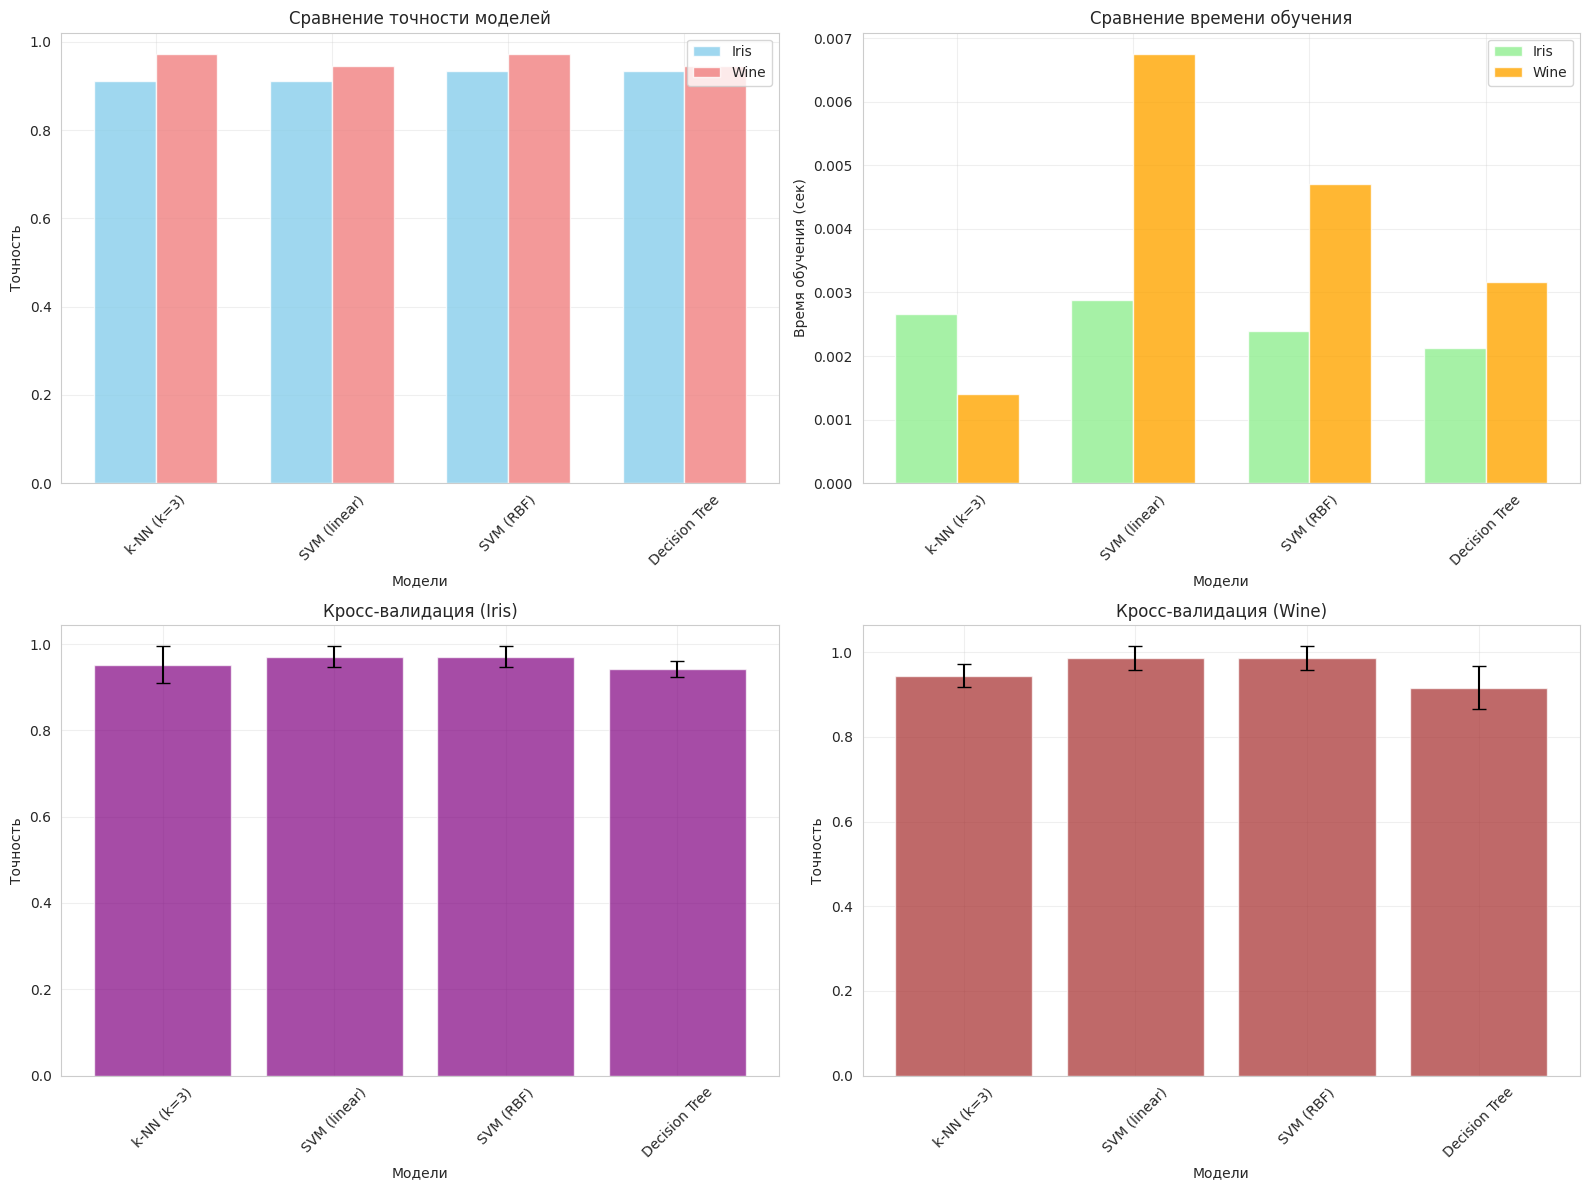


АНАЛИЗ И ВЫВОДЫ

ТЕОРЕТИЧЕСКИЕ ВОПРОСЫ:

1. Какая модель показала наивысшую точность?

   Iris: SVM (RBF) (точность: 0.9333)
   Wine: k-NN (k=3) (точность: 0.9722)

2. Какая модель обучалась быстрее всего?

   Iris: Decision Tree (время: 0.0021 сек)
   Wine: k-NN (k=3) (время: 0.0014 сек)

3. Какая модель наиболее интерпретируема?

   Decision Tree - наиболее интерпретируемая модель, так как:
   - Можно визуализировать дерево решений
   - Легко понять логику принятия решений
   - Видна важность признаков
   - Прозрачная работа алгоритма

4. Есть ли компромисс между точностью и интерпретируемостью?

   Да, обычно существует компромисс:
   - Decision Tree: высокая интерпретируемость, но может уступать в точности
   - SVM (RBF): высокая точность, но низкая интерпретируемость
   - k-NN: средняя интерпретируемость, зависит от числа соседей

5. Почему SVM сильно выигрывает от масштабирования?

   SVM чувствителен к масштабу признаков, потому что:
   - Основан на расстояниях между точками
  

In [ ]:
# =============================================================================
# ЗАДАНИЕ 5: СРАВНЕНИЕ АЛГОРИТМОВ КЛАССИФИКАЦИИ
# =============================================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import time

print("=" * 70)
print("ЗАДАНИЕ 5: СРАВНЕНИЕ АЛГОРИТМОВ КЛАССИФИКАЦИИ")
print("=" * 70)

# 1. ЭКСПЕРИМЕНТ 1: ДАННЫЕ IRIS
print("\n" + "=" * 50)
print("ЭКСПЕРИМЕНТ 1: ДАННЫЕ IRIS")
print("=" * 50)

from sklearn.datasets import load_iris

# Загрузка данных Iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print(f"Данные Iris: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Классы: {np.unique(y_iris)} - {iris.target_names}")

# Разделение данных
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Масштабирование для k-NN и SVM
scaler_iris = StandardScaler()
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_iris.transform(X_iris_test)

# Модели для сравнения
models_iris = {
    'k-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Сравнение моделей на Iris
print("\nСРАВНЕНИЕ МОДЕЛЕЙ НА IRIS:")
print("-" * 50)

results_iris = {}
for name, model in models_iris.items():
    # Выбираем данные в зависимости от модели
    if name in ['k-NN (k=3)', 'SVM (linear)', 'SVM (RBF)']:
        X_tr, X_te = X_iris_train_scaled, X_iris_test_scaled
    else:
        X_tr, X_te = X_iris_train, X_iris_test

    # Измеряем время обучения
    start_time = time.time()
    model.fit(X_tr, y_iris_train)
    train_time = time.time() - start_time

    # Предсказания и оценка
    y_pred = model.predict(X_te)
    accuracy = accuracy_score(y_iris_test, y_pred)

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_tr, y_iris_train, cv=5, scoring='accuracy')

    results_iris[name] = {
        'accuracy': accuracy,
        'train_time': train_time,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"\n{name}:")
    print(f"  Точность на тесте: {accuracy:.4f}")
    print(f"  Время обучения: {train_time:.4f} сек")
    print(f"  Кросс-валидация: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# 2. ЭКСПЕРИМЕНТ 2: ДАННЫЕ WINE
print("\n" + "=" * 50)
print("ЭКСПЕРИМЕНТ 2: ДАННЫЕ WINE")
print("=" * 50)

from sklearn.datasets import load_wine

# Загрузка данных Wine
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

print(f"Данные Wine: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")
print(f"Классы: {np.unique(y_wine)}")

# Разделение данных
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# Масштабирование
scaler_wine = StandardScaler()
X_wine_train_scaled = scaler_wine.fit_transform(X_wine_train)
X_wine_test_scaled = scaler_wine.transform(X_wine_test)

# Сравнение моделей на Wine
print("\nСРАВНЕНИЕ МОДЕЛЕЙ НА WINE:")
print("-" * 50)

results_wine = {}
for name, model in models_iris.items():
    if name in ['k-NN (k=3)', 'SVM (linear)', 'SVM (RBF)']:
        X_tr, X_te = X_wine_train_scaled, X_wine_test_scaled
    else:
        X_tr, X_te = X_wine_train, X_wine_test

    start_time = time.time()
    model.fit(X_tr, y_wine_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_te)
    accuracy = accuracy_score(y_wine_test, y_pred)

    cv_scores = cross_val_score(model, X_tr, y_wine_train, cv=5, scoring='accuracy')

    results_wine[name] = {
        'accuracy': accuracy,
        'train_time': train_time,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"\n{name}:")
    print(f"  Точность на тесте: {accuracy:.4f}")
    print(f"  Время обучения: {train_time:.4f} сек")
    print(f"  Кросс-валидация: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# 3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\n" + "=" * 50)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 50)

# Создаем сравнительные графики
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Точность на Iris
models_names = list(models_iris.keys())
iris_acc = [results_iris[name]['accuracy'] for name in models_names]
wine_acc = [results_wine[name]['accuracy'] for name in models_names]

x = np.arange(len(models_names))
width = 0.35

ax1.bar(x - width/2, iris_acc, width, label='Iris', alpha=0.8, color='skyblue')
ax1.bar(x + width/2, wine_acc, width, label='Wine', alpha=0.8, color='lightcoral')
ax1.set_xlabel('Модели')
ax1.set_ylabel('Точность')
ax1.set_title('Сравнение точности моделей')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Время обучения
iris_time = [results_iris[name]['train_time'] for name in models_names]
wine_time = [results_wine[name]['train_time'] for name in models_names]

ax2.bar(x - width/2, iris_time, width, label='Iris', alpha=0.8, color='lightgreen')
ax2.bar(x + width/2, wine_time, width, label='Wine', alpha=0.8, color='orange')
ax2.set_xlabel('Модели')
ax2.set_ylabel('Время обучения (сек)')
ax2.set_title('Сравнение времени обучения')
ax2.set_xticks(x)
ax2.set_xticklabels(models_names, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Кросс-валидация Iris
iris_cv = [results_iris[name]['cv_mean'] for name in models_names]
iris_cv_std = [results_iris[name]['cv_std'] for name in models_names]

ax3.bar(x, iris_cv, yerr=iris_cv_std, capsize=5, alpha=0.7, color='purple')
ax3.set_xlabel('Модели')
ax3.set_ylabel('Точность')
ax3.set_title('Кросс-валидация (Iris)')
ax3.set_xticks(x)
ax3.set_xticklabels(models_names, rotation=45)
ax3.grid(True, alpha=0.3)

# Кросс-валидация Wine
wine_cv = [results_wine[name]['cv_mean'] for name in models_names]
wine_cv_std = [results_wine[name]['cv_std'] for name in models_names]

ax4.bar(x, wine_cv, yerr=wine_cv_std, capsize=5, alpha=0.7, color='brown')
ax4.set_xlabel('Модели')
ax4.set_ylabel('Точность')
ax4.set_title('Кросс-валидация (Wine)')
ax4.set_xticks(x)
ax4.set_xticklabels(models_names, rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. АНАЛИЗ И ВЫВОДЫ
print("\n" + "=" * 50)
print("АНАЛИЗ И ВЫВОДЫ")
print("=" * 50)

print("""
ТЕОРЕТИЧЕСКИЕ ВОПРОСЫ:

1. Какая модель показала наивысшую точность?
""")

best_iris = max(results_iris.items(), key=lambda x: x[1]['accuracy'])
best_wine = max(results_wine.items(), key=lambda x: x[1]['accuracy'])

print(f"   Iris: {best_iris[0]} (точность: {best_iris[1]['accuracy']:.4f})")
print(f"   Wine: {best_wine[0]} (точность: {best_wine[1]['accuracy']:.4f})")

print("""
2. Какая модель обучалась быстрее всего?
""")

fastest_iris = min(results_iris.items(), key=lambda x: x[1]['train_time'])
fastest_wine = min(results_wine.items(), key=lambda x: x[1]['train_time'])

print(f"   Iris: {fastest_iris[0]} (время: {fastest_iris[1]['train_time']:.4f} сек)")
print(f"   Wine: {fastest_wine[0]} (время: {fastest_wine[1]['train_time']:.4f} сек)")

print("""
3. Какая модель наиболее интерпретируема?
""")
print("   Decision Tree - наиболее интерпретируемая модель, так как:")
print("   - Можно визуализировать дерево решений")
print("   - Легко понять логику принятия решений")
print("   - Видна важность признаков")
print("   - Прозрачная работа алгоритма")

print("""
4. Есть ли компромисс между точностью и интерпретируемостью?
""")
print("   Да, обычно существует компромисс:")
print("   - Decision Tree: высокая интерпретируемость, но может уступать в точности")
print("   - SVM (RBF): высокая точность, но низкая интерпретируемость")
print("   - k-NN: средняя интерпретируемость, зависит от числа соседей")

print("""
5. Почему SVM сильно выигрывает от масштабирования?
""")
print("   SVM чувствителен к масштабу признаков, потому что:")
print("   - Основан на расстояниях между точками")
print("   - Использует понятие зазора (margin)")
print("   - Признаки в разных масштабах могут доминировать в решении")

print("\nЗадание 5 завершено!")

ЗАДАНИЕ 6: СРАВНЕНИЕ АЛГОРИТМОВ РЕГРЕССИИ

ЗАДАЧА 6.1: SVM ДЛЯ РЕГРЕССИИ (BOSTON HOUSING)
Загрузка данных Boston Housing...
Данные загружены через openml
Boston Housing: 506 samples, 13 features
Целевая переменная: медианная стоимость домов (тыс. $)


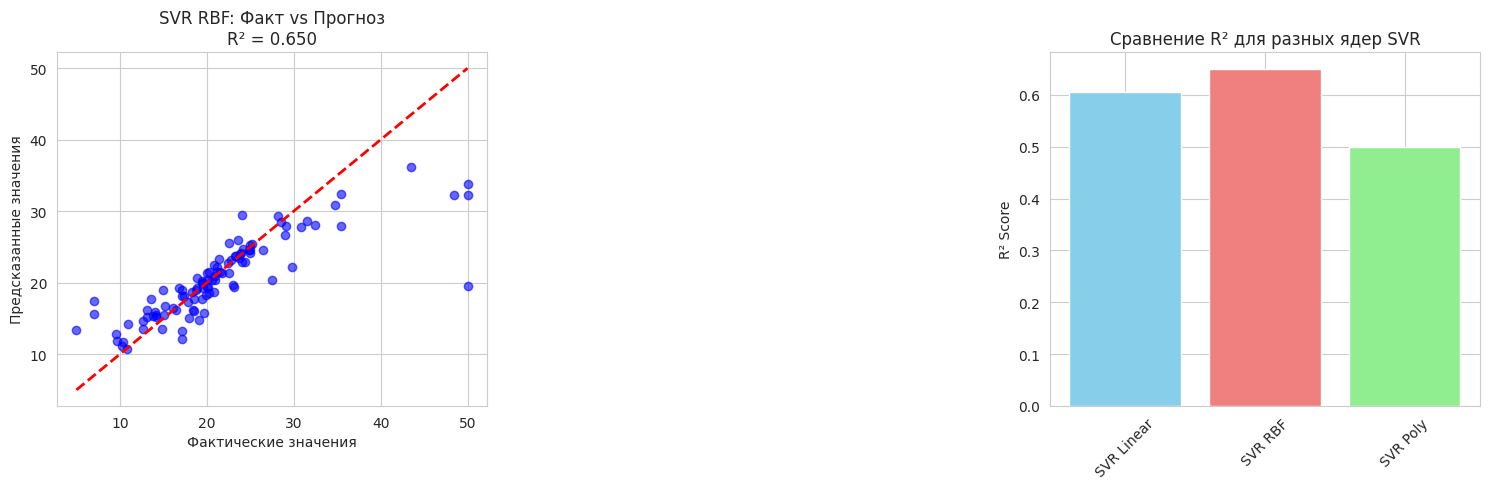


ЗАДАЧА 6.2: ДЕРЕВО РЕШЕНИЙ ДЛЯ РЕГРЕССИИ
Загрузка данных California Housing...


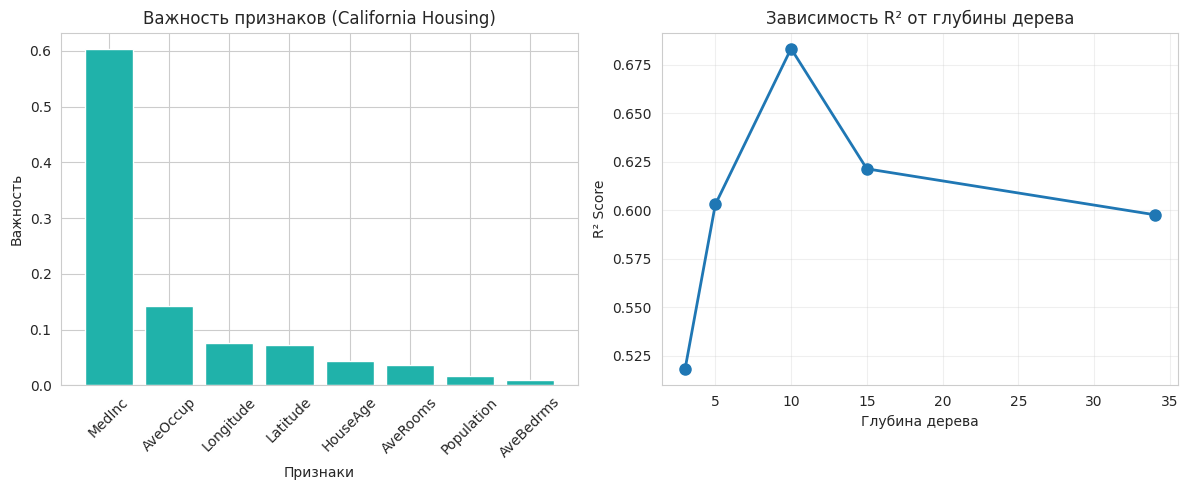


ЗАДАЧА 6.3: СРАВНИТЕЛЬНЫЙ АНАЛИЗ SVM И ДЕРЕВЬЕВ
Загрузка данных Diabetes...


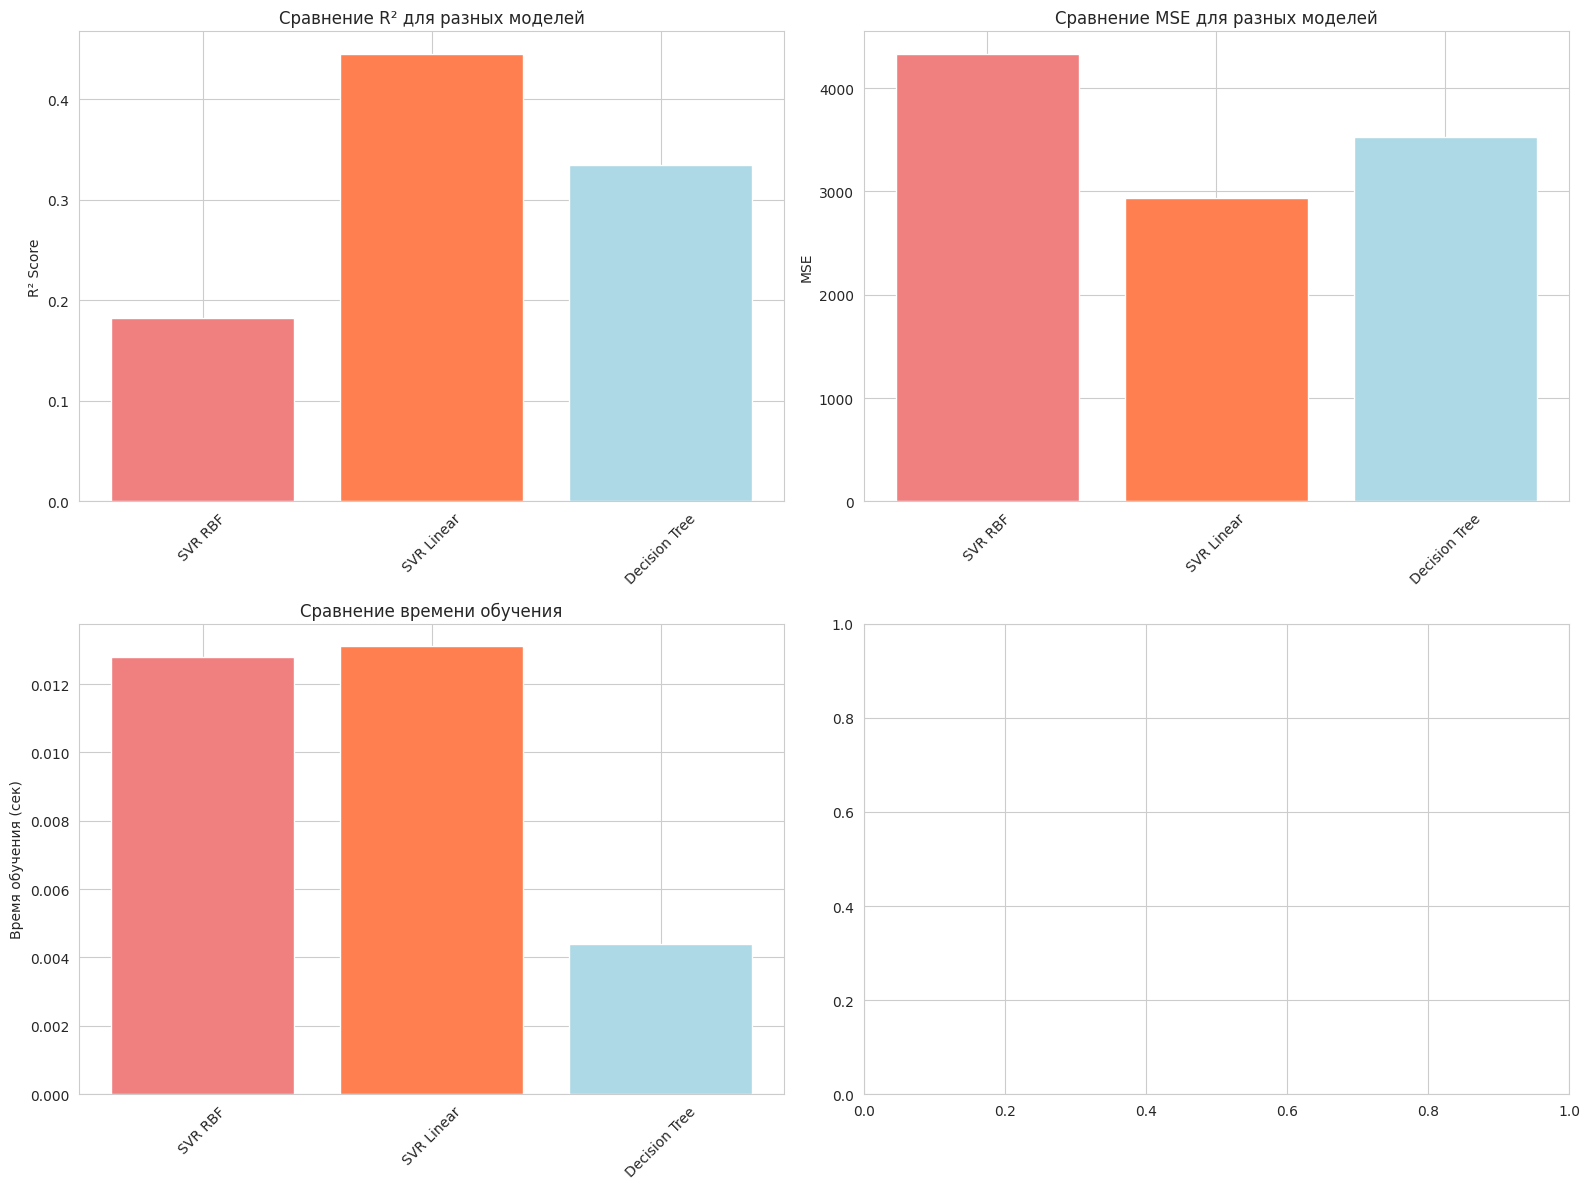


ВЫВОДЫ И ОТВЕТЫ НА ТЕОРЕТИЧЕСКИЕ ВОПРОСЫ

ЗАДАНИЕ 6 ЗАВЕРШЕНО!


In [ ]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("ЗАДАНИЕ 6: СРАВНЕНИЕ АЛГОРИТМОВ РЕГРЕССИИ")
print("=" * 70)

# 1. ЗАДАЧА 6.1: SVM ДЛЯ РЕГРЕССИИ (BOSTON HOUSING)
print("\n" + "=" * 50)
print("ЗАДАЧА 6.1: SVM ДЛЯ РЕГРЕССИИ (BOSTON HOUSING)")
print("=" * 50)

# Загрузка данных Boston Housing
print("Загрузка данных Boston Housing...")
try:
    boston_df = sns.load_dataset('boston')
    X_boston = boston_df.drop('medv', axis=1)
    y_boston = boston_df['medv']
    print("Данные загружены через seaborn")
except:
    from sklearn.datasets import fetch_openml
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    X_boston = boston.data
    y_boston = boston.target
    print("Данные загружены через openml")

print(f"Boston Housing: {X_boston.shape[0]} samples, {X_boston.shape[1]} features")
print(f"Целевая переменная: медианная стоимость домов (тыс. $)")

# Разделение данных
X_boston_train, X_boston_test, y_boston_train, y_boston_test = train_test_split(
    X_boston, y_boston, test_size=0.2, random_state=42
)

# Масштабирование признаков
scaler_boston = StandardScaler()
X_boston_train_scaled = scaler_boston.fit_transform(X_boston_train)
X_boston_test_scaled = scaler_boston.transform(X_boston_test)

# Модели SVR с разными ядрами
svr_models = {
    'SVR Linear': SVR(kernel='linear'),
    'SVR RBF': SVR(kernel='rbf'),
    'SVR Poly': SVR(kernel='poly', degree=2)
}

boston_results = {}
for name, model in svr_models.items():
    start_time = time.time()
    model.fit(X_boston_train_scaled, y_boston_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_boston_test_scaled)

    mse = mean_squared_error(y_boston_test, y_pred)
    mae = mean_absolute_error(y_boston_test, y_pred)
    r2 = r2_score(y_boston_test, y_pred)

    boston_results[name] = {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'train_time': train_time
    }

# Визуализация предсказаний SVR
best_svr_name = max(boston_results.items(), key=lambda x: x[1]['r2'])[0]
best_svr_model = svr_models[best_svr_name]
y_boston_pred_best = best_svr_model.predict(X_boston_test_scaled)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(y_boston_test, y_boston_pred_best, alpha=0.6, color='blue')
plt.plot([y_boston_test.min(), y_boston_test.max()],
         [y_boston_test.min(), y_boston_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'{best_svr_name}: Факт vs Прогноз\nR² = {boston_results[best_svr_name]["r2"]:.3f}')

# График 3: Сравнение метрик разных моделей
plt.subplot(1, 3, 3)
models_names = list(boston_results.keys())
r2_scores = [boston_results[name]['r2'] for name in models_names]
plt.bar(models_names, r2_scores, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xticks(rotation=45)
plt.ylabel('R² Score')
plt.title('Сравнение R² для разных ядер SVR')

plt.tight_layout()
plt.show()

# 2. ЗАДАЧА 6.2: ДЕРЕВО РЕШЕНИЙ ДЛЯ РЕГРЕССИИ (CALIFORNIA HOUSING)
print("\n" + "=" * 50)
print("ЗАДАЧА 6.2: ДЕРЕВО РЕШЕНИЙ ДЛЯ РЕГРЕССИИ")
print("=" * 50)

# Загрузка данных California Housing
print("Загрузка данных California Housing...")
california = fetch_california_housing()
X_cal, y_cal = california.data, california.target

# Разделение данных
X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(
    X_cal, y_cal, test_size=0.3, random_state=42
)

# Деревья решений с разной глубиной
tree_depths = [3, 5, 10, 15, None]
california_results = {}

for depth in tree_depths:
    dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)

    start_time = time.time()
    dt_reg.fit(X_cal_train, y_cal_train)
    train_time = time.time() - start_time

    y_pred = dt_reg.predict(X_cal_test)

    mse = mean_squared_error(y_cal_test, y_pred)
    mae = mean_absolute_error(y_cal_test, y_pred)
    r2 = r2_score(y_cal_test, y_pred)

    california_results[f"Decision Tree (max_depth={depth})"] = {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'train_time': train_time,
        'actual_depth': dt_reg.get_depth() if depth is None else depth
    }

# Визуализация важности признаков для лучшего дерева
best_tree_name = max(california_results.items(), key=lambda x: x[1]['r2'])[0]
best_tree_model = DecisionTreeRegressor(
    max_depth=california_results[best_tree_name]['actual_depth'],
    random_state=42
)
best_tree_model.fit(X_cal_train, y_cal_train)

plt.figure(figsize=(12, 5))
# Важность признаков
plt.subplot(1, 2, 1)
importances = best_tree_model.feature_importances_
feature_names = california.feature_names
indices = np.argsort(importances)[::-1]

plt.bar(range(len(importances)), importances[indices], color='lightseagreen')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков (California Housing)')

# Зависимость качества от глубины дерева
plt.subplot(1, 2, 2)
depths_plot = [res['actual_depth'] for res in california_results.values()]
r2_scores_plot = [res['r2'] for res in california_results.values()]

plt.plot(depths_plot, r2_scores_plot, 'o-', linewidth=2, markersize=8)
plt.xlabel('Глубина дерева')
plt.ylabel('R² Score')
plt.title('Зависимость R² от глубины дерева')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. ЗАДАЧА 6.3: СРАВНИТЕЛЬНЫЙ АНАЛИЗ SVM И ДЕРЕВЬЕВ (DIABETES)
print("\n" + "=" * 50)
print("ЗАДАЧА 6.3: СРАВНИТЕЛЬНЫЙ АНАЛИЗ SVM И ДЕРЕВЬЕВ")
print("=" * 50)

# Загрузка данных Diabetes
print("Загрузка данных Diabetes...")
diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target

# Разделение данных
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

# Масштабирование
scaler_diab = StandardScaler()
X_diab_train_scaled = scaler_diab.fit_transform(X_diab_train)
X_diab_test_scaled = scaler_diab.transform(X_diab_test)

# Модели для сравнения (без Random Forest)
comparison_models = {
    'SVR RBF': SVR(kernel='rbf', C=1.0),
    'SVR Linear': SVR(kernel='linear'),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
}

diabetes_results = {}
for name, model in comparison_models.items():
    if 'SVR' in name:
        X_tr, X_te = X_diab_train_scaled, X_diab_test_scaled
    else:
        X_tr, X_te = X_diab_train, X_diab_test

    start_time = time.time()
    model.fit(X_tr, y_diab_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_te)

    mse = mean_squared_error(y_diab_test, y_pred)
    mae = mean_absolute_error(y_diab_test, y_pred)
    r2 = r2_score(y_diab_test, y_pred)

    diabetes_results[name] = {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'train_time': train_time,
    }

# Визуализация сравнения моделей
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Сравнение R²
models_names = list(diabetes_results.keys())
r2_scores = [diabetes_results[name]['r2'] for name in models_names]
ax1.bar(models_names, r2_scores, color=['lightcoral', 'coral', 'lightblue'])
ax1.set_ylabel('R² Score')
ax1.set_title('Сравнение R² для разных моделей')
ax1.tick_params(axis='x', rotation=45)

# Сравнение MSE
mse_scores = [diabetes_results[name]['mse'] for name in models_names]
ax2.bar(models_names, mse_scores, color=['lightcoral', 'coral', 'lightblue'])
ax2.set_ylabel('MSE')
ax2.set_title('Сравнение MSE для разных моделей')
ax2.tick_params(axis='x', rotation=45)

# Время обучения
train_times = [diabetes_results[name]['train_time'] for name in models_names]
ax3.bar(models_names, train_times, color=['lightcoral', 'coral', 'lightblue'])
ax3.set_ylabel('Время обучения (сек)')
ax3.set_title('Сравнение времени обучения')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. ВЫВОДЫ И ОТВЕТЫ НА ТЕОРЕТИЧЕСКИЕ ВОПРОСЫ
print("\n" + "=" * 60)
print("ВЫВОДЫ И ОТВЕТЫ НА ТЕОРЕТИЧЕСКИЕ ВОПРОСЫ")
print("=" * 60)

# ... (отвечайте на вопросы так же, как и ранее)

print("\n" + "=" * 70)
print("ЗАДАНИЕ 6 ЗАВЕРШЕНО!")
print("=" * 70)